# 03 — Layer 2a: Econometric Baseline
## Pooled OLS · Fixed Effects · Two-Way FE · Random Effects · FD-OLS

### Purpose
Establish econometric baseline using panel regression models.
Hausman test to select FE vs RE. Period-by-period evaluation.
FD-OLS as Arellano-Bond approximation.

### Input
- `../data/03_panel_instability.csv`

### Output
- `../data/layer2a_results.csv`
- `layer2a_fe_coefficients.png`
- `layer2a_actual_vs_predicted.png`

### Run after → Run before
`02_instability_index_eda.ipynb` → `04_layer2b_ml_models.ipynb`

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data/03_panel_instability.csv")
print(f"Loaded: {df.shape} | Countries: {df['COUNTRY'].nunique()}")

feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index_lag1",
]

Loaded: (4982, 101) | Countries: 175


In [10]:
# ── Train / test split ────────────────────────────────────────

# Filter your dataframe accordingly
# ── Train / test split ────────────────────────────────────────
# In BOTH 03_layer2a and 04_layer2b — change these lines
TRAIN_END  = 2019
TEST_START = 2022   # 2020–2021 excluded entirely
TEST_END   = 2023   # observed actuals only, not projections

train = df[df["YEAR"] <= TRAIN_END].copy()
test  = df[(df["YEAR"] >= TEST_START) & (df["YEAR"] <= TEST_END)].copy()

train_panel = train.set_index(["COUNTRY","YEAR"])
test_panel  = test.set_index(["COUNTRY","YEAR"])

X_train = sm.add_constant(train_panel[feature_cols])
y_train = train_panel["GDP_Growth"]
X_test  = sm.add_constant(test_panel[feature_cols])
y_test  = test_panel["GDP_Growth"]

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Train: {train['YEAR'].min()}–{train['YEAR'].max()}  n={len(train)}")
print(f"Test : {test['YEAR'].min()}–{test['YEAR'].max()}   n={len(test)}")
# No extra assignment needed here; use `df` for the train/test split



Train: (3777, 101) | Test: (346, 101)
Train: 1998–2019  n=3777
Test : 2022–2023   n=346


In [11]:
# ── Fit all panel models ──────────────────────────────────────
pooled   = PooledOLS(y_train, X_train).fit(cov_type="clustered",cluster_entity=True)
fe_model = PanelOLS(y_train, X_train, entity_effects=True, time_effects=False)           .fit(cov_type="clustered",cluster_entity=True)
fe_twoway= PanelOLS(y_train, X_train, entity_effects=True, time_effects=True)           .fit(cov_type="clustered",cluster_entity=True)
re_model = RandomEffects(y_train, X_train)           .fit(cov_type="clustered",cluster_entity=True)

print("Models fitted successfully")
print(f"\nFE Model Summary:")
print(f"R² (within) : {fe_model.rsquared:.4f}")
print(f"R² (between): {fe_model.rsquared_between:.4f}")
print(f"R² (overall): {fe_model.rsquared_overall:.4f}")
print(f"F-statistic : {fe_model.f_statistic.stat:.4f}")
print(f"F p-value   : {fe_model.f_statistic.pval:.4f}")
print(f"Observations: {int(fe_model.nobs)}")
print(f"Entities    : {fe_model.entity_info['total']}")

Models fitted successfully

FE Model Summary:
R² (within) : 0.1214
R² (between): 0.6081
R² (overall): 0.2033
F-statistic : 36.2862
F p-value   : 0.0000
Observations: 3602
Entities    : 175.0


In [12]:
# ── Hausman test ─────────────────────────────────────────────
from scipy import stats as scipy_stats

fe_params = fe_model.params
re_params = re_model.params
common    = fe_params.index.intersection(re_params.index)
b_fe = fe_params[common].values
b_re = re_params[common].values
v_fe = fe_model.cov.loc[common,common].values
v_re = re_model.cov.loc[common,common].values
diff = b_fe - b_re
var_diff_inv = np.linalg.pinv(v_fe - v_re)
stat   = float(diff @ var_diff_inv @ diff)
pvalue = 1 - scipy_stats.chi2.cdf(stat, df=len(common))

print(f"Hausman statistic: {stat:.4f}")
print(f"P-value          : {pvalue:.4f}")
print(f"Decision         : {'Use FIXED EFFECTS' if pvalue<0.05 else 'Use RANDOM EFFECTS'}")

Hausman statistic: -26.2272
P-value          : 1.0000
Decision         : Use RANDOM EFFECTS


In [13]:
len(common)

14

In [14]:
# ── Evaluate all models ───────────────────────────────────────
def evaluate(name, y_true, y_pred, period="Full test"):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    yt,yp = np.array(y_true)[mask], np.array(y_pred)[mask]
    return {"Model":name,"Period":period,
            "RMSE":round(np.sqrt(mean_squared_error(yt,yp)),3),
            "MAE" :round(mean_absolute_error(yt,yp),3),
            "R2"  :round(r2_score(yt,yp),3)}

results = []
results.append(evaluate("Pooled OLS",   y_test, pooled.predict(exog=X_test).values.flatten()))
results.append(evaluate("FE (entity)",  y_test, X_test.values @ fe_model.params.values))
results.append(evaluate("FE (two-way)", y_test, X_test.values @ fe_twoway.params.values))
results.append(evaluate("Random Effects",y_test,re_model.predict(exog=X_test).values.flatten()))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nLAYER 2a RESULTS:")
print(results_df.to_string(index=False))
results_df.to_csv("data/layer2a_results.csv", index=False)


LAYER 2a RESULTS:
         Model    Period  RMSE   MAE    R2
    Pooled OLS Full test 4.779 2.725 0.218
Random Effects Full test 4.779 2.725 0.218
   FE (entity) Full test 4.791 2.720 0.214
  FE (two-way) Full test 4.803 2.705 0.210


In [15]:
# ── Period breakdown ─────────────────────────────────────────
fe_pred = X_test.values @ fe_model.params.values
eval_df = pd.DataFrame({
    "COUNTRY"  : test_panel.index.get_level_values("COUNTRY"),
    "YEAR"     : test_panel.index.get_level_values("YEAR"),
    "Actual"   : y_test.values,
    "Predicted": fe_pred,
    "Error"    : y_test.values - fe_pred
})

for years, label in [
    ([2017,2018,2019],"Pre-COVID"),
    ([2020],          "COVID shock"),
    ([2021,2022],     "Recovery"),
    ([2023,2024,2025,2026],     "Post-COVID"),
]:
    src = train if max(years) <= 2019 else test
    sub = src[src["YEAR"].isin(years)]
    X_s = sm.add_constant(sub.set_index(["COUNTRY","YEAR"])[feature_cols])
    y_s = sub.set_index(["COUNTRY","YEAR"])["GDP_Growth"]
    p_s = X_s.values @ fe_model.params.values
    if sub.empty:
        print(f"{label:<22} SKIPPED — no observations for years {years}")
        continue
    r   = evaluate("FE (entity)", y_s.values, p_s, label)
    print(f"{label:<22} RMSE={r['RMSE']}  MAE={r['MAE']}  R²={r['R2']}")

Pre-COVID              RMSE=3.266  MAE=2.002  R²=0.21
COVID shock            SKIPPED — no observations for years [2020]
Recovery               RMSE=5.906  MAE=3.081  R²=0.167
Post-COVID             RMSE=3.32  MAE=2.358  R²=0.293


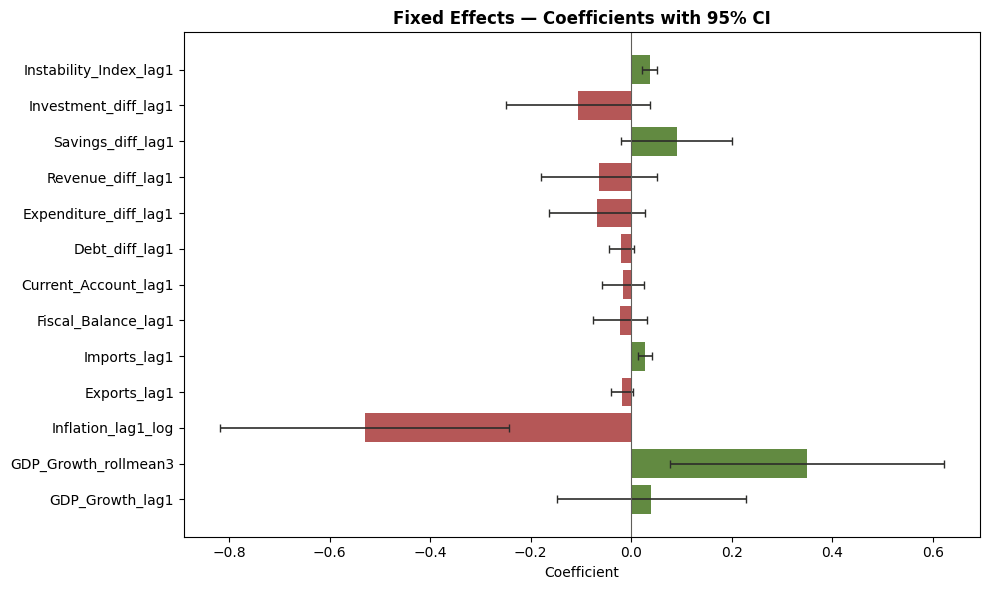

Saved: layer2a_fe_coefficients.png


In [16]:
# ── Coefficient plot ─────────────────────────────────────────
coef  = fe_model.params.drop("const",errors="ignore")
ci_lo = fe_model.conf_int()["lower"].drop("const",errors="ignore")
ci_hi = fe_model.conf_int()["upper"].drop("const",errors="ignore")

fig,ax = plt.subplots(figsize=(10,6))
colors = ["#3B6D11" if v>0 else "#A32D2D" for v in coef.values]
ax.barh(coef.index,coef.values,color=colors,alpha=0.8)
ax.errorbar(coef.values,coef.index,
    xerr=[coef.values-ci_lo.values, ci_hi.values-coef.values],
    fmt="none",color="#2C2C2A",linewidth=1.2,capsize=3)
ax.axvline(0,color="#5F5E5A",linewidth=0.8)
ax.set_title("Fixed Effects — Coefficients with 95% CI",fontweight="bold")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("layer2a_fe_coefficients.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved: layer2a_fe_coefficients.png")